In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("../Dataset/Orders.csv")

orders["Order_Date"] = pd.to_datetime(
    orders["Order_Date"]
)

How many units are sold every month?

In [3]:
monthly_demand = (

    orders
    .groupby(
        orders["Order_Date"].dt.to_period("M")
    )["Quantity"]
    .sum()

)

monthly_demand = monthly_demand.to_frame()

monthly_demand

,Quantity
Order_Date,
2023-01,1752
2023-02,1661
2023-03,1677
2023-04,1777
2023-05,1569
2023-06,1843
2023-07,1909
2023-08,1809
2023-09,1636


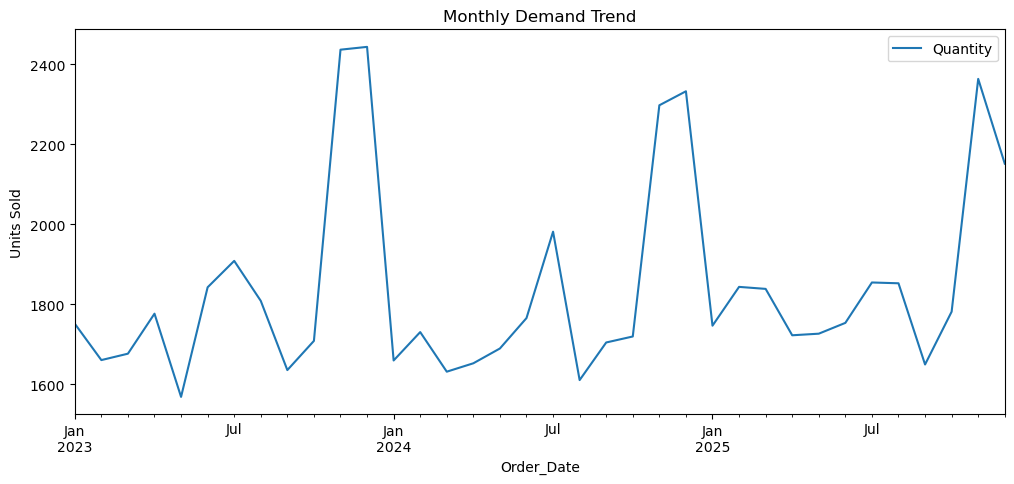

In [4]:
monthly_demand.plot(
    figsize=(12,5)
)

plt.title("Monthly Demand Trend")
plt.ylabel("Units Sold")

plt.show()

In [5]:
monthly_revenue = (

    orders
    .groupby(
        orders["Order_Date"].dt.to_period("M")
    )["Revenue"]
    .sum()

)

monthly_revenue = monthly_revenue.to_frame()

monthly_revenue

,Revenue
Order_Date,
2023-01,512498
2023-02,437239
2023-03,426993
2023-04,509003
2023-05,482221
2023-06,560337
2023-07,495671
2023-08,591571
2023-09,484254


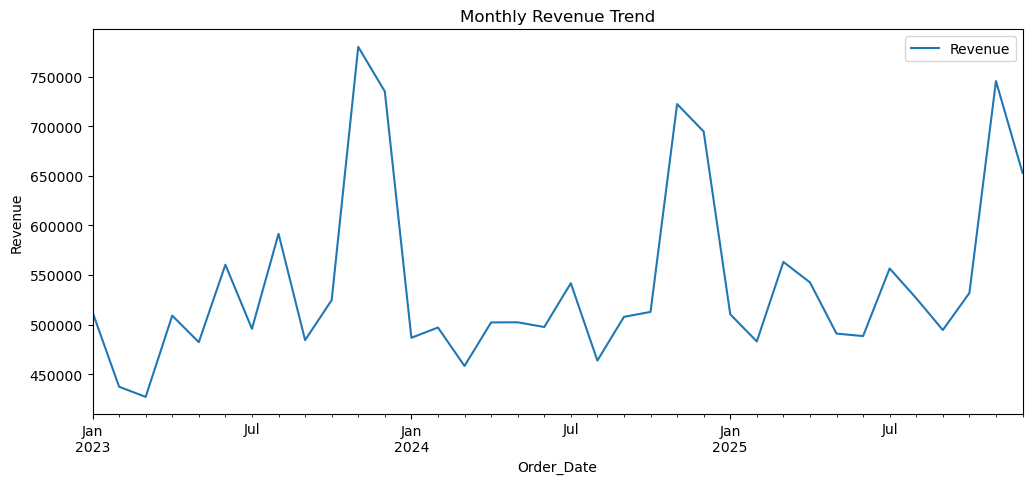

In [6]:
monthly_revenue.plot(
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.show()

In [7]:
monthly_demand["Forecast"] = (
    monthly_demand["Quantity"]
    .rolling(3)
    .mean()
)

monthly_demand

,Quantity,Forecast
Order_Date,,
2023-01,1752,NaN
2023-02,1661,NaN
2023-03,1677,1696.666667
2023-04,1777,1705.000000
2023-05,1569,1674.333333
2023-06,1843,1729.666667
2023-07,1909,1773.666667
2023-08,1809,1853.666667
2023-09,1636,1784.666667


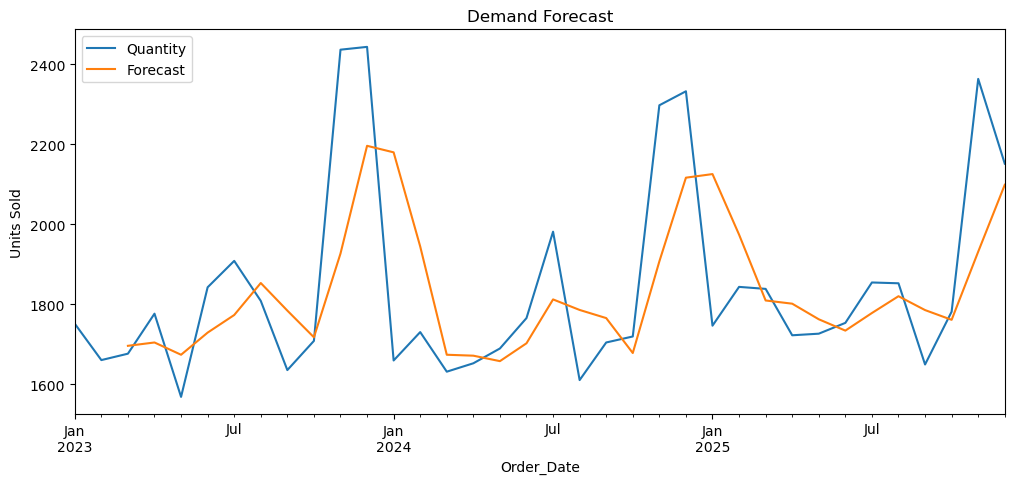

In [8]:
monthly_demand.plot(
    figsize=(12,5)
)

plt.title("Demand Forecast")
plt.ylabel("Units Sold")

plt.show()

In [9]:
monthly_revenue["Forecast"] = (
    monthly_revenue["Revenue"]
    .rolling(3)
    .mean()
)

monthly_revenue

,Revenue,Forecast
Order_Date,,
2023-01,512498,NaN
2023-02,437239,NaN
2023-03,426993,458910.000000
2023-04,509003,457745.000000
2023-05,482221,472739.000000
2023-06,560337,517187.000000
2023-07,495671,512743.000000
2023-08,591571,549193.000000
2023-09,484254,523832.000000


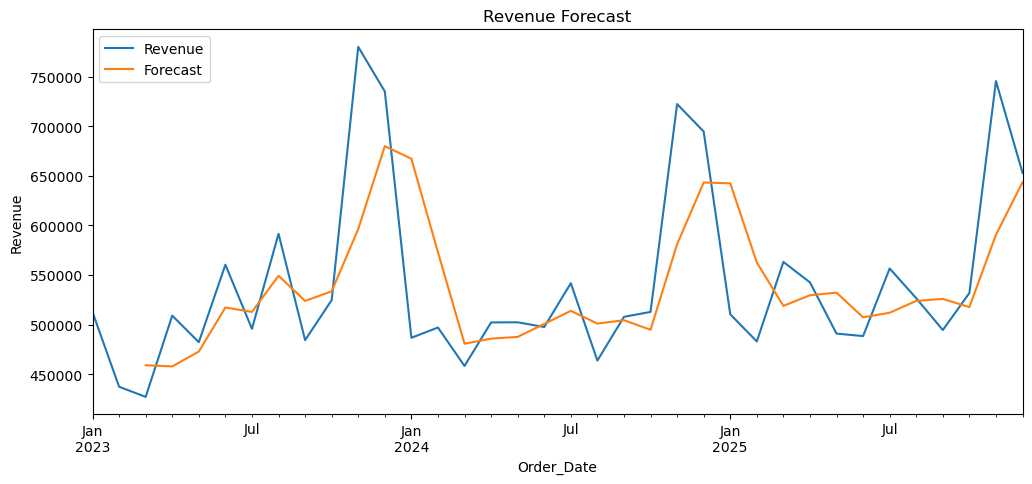

In [10]:
monthly_revenue.plot(
    figsize=(12,5)
)

plt.title("Revenue Forecast")
plt.ylabel("Revenue")

plt.show()

In [11]:
inventory = pd.read_csv(
    "../Dataset/Inventory.csv"
)

inventory.head()

,Inventory_ID,Product_ID,Warehouse_ID,Stock_Level,Reorder_Point,Inventory_Status
0,I001,P001,W001,850,300,Healthy
1,I002,P002,W001,220,400,Low Stock
2,I003,P003,W001,600,250,Healthy
3,I004,P004,W001,450,200,Healthy
4,I005,P005,W001,180,250,Low Stock


In [12]:
reorder_alerts = inventory[
    inventory["Stock_Level"]
    <=
    inventory["Reorder_Point"]
]

reorder_alerts

,Inventory_ID,Product_ID,Warehouse_ID,Stock_Level,Reorder_Point,Inventory_Status
1,I002,P002,W001,220,400,Low Stock
4,I005,P005,W001,180,250,Low Stock
6,I007,P007,W002,350,400,Low Stock
11,I012,P012,W003,280,400,Low Stock
14,I015,P015,W004,150,250,Low Stock
16,I017,P017,W004,180,400,Low Stock
19,I020,P020,W005,140,250,Low Stock
21,I022,P022,W005,150,400,Low Stock
24,I025,P025,W005,100,250,Low Stock


In [13]:
print(
    "Products Requiring Reorder:",
    len(reorder_alerts)
)

Products Requiring Reorder: 9
